In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from dateutil.relativedelta import relativedelta

from data.loader import fetch_prices
from pairs.selection import test_cointegration, compute_spread
from pairs.metrics import fit_ou
from strategy.walk_forward import run_walk_forward, run_parameter_grid
from analysis.performance import summarize

## Starting with What Worked

In notebook 06 we tested eight pairs and got a clear answer: most of them had no persistent edge out-of-sample. Two did: KO/PEP (Sharpe 0.48) and NUE/STLD (Sharpe 0.29). The rest either broke even or lost money consistently.

KO/PEP was not a surprise. Coca-Cola and PepsiCo are the two dominant beverage companies in the world. They compete for the same shelf space, the same consumers, the same distribution channels. Their input costs move together: high-fructose corn syrup, aluminum cans, PET plastic. When one gets hit by a supply shock, so does the other.

A Sharpe of 0.48 out-of-sample, after transaction costs, across 12 separate test years, is a real result. But the thresholds used throughout (entry at z=2.0, exit at z=0.0) were inherited from notebook 02. They were never tested specifically for this pair.

This notebook has two goals:
1. Verify that the KO/PEP economic story actually shows up in the data. How stable is the cointegration? How long does a typical reversion take? Does the relationship hold in every subperiod?
2. Test whether adjusting the entry and exit thresholds improves the Sharpe, evaluated using walk-forward out-of-sample results only.

In [2]:
T1, T2 = 'KO', 'PEP'
START = '2010-01-01'
END   = '2024-12-31'
TRAIN_YEARS = 2
TEST_YEARS  = 1
COST_BPS = 5.0

# Baseline thresholds (from notebook 06)
ENTRY_Z_BASE = 2.0
EXIT_Z_BASE  = 0.0
STOP_Z_BASE  = 3.0

## 1. Why KO/PEP: The Economic Story in the Data

Before optimizing anything, I want to verify that the economic story shows up in the data. A Sharpe of 0.48 is encouraging, but it is worth checking: is the cointegration relationship actually stable across the full 15 years, or was it concentrated in one particular period?

Three checks:
- Full-sample cointegration stats and OU half-life
- A plot of the 15-year spread
- Cointegration stats per training window (is the relationship stable, or does it come and go?)

In [3]:
prices = fetch_prices([T1, T2], START, END)

coint_full = test_cointegration(prices[T1], prices[T2])
spread_full = compute_spread(prices, T1, T2, coint_full['hedge_ratio'])
ou_full = fit_ou(spread_full)

print(f"Full-sample cointegration stats ({prices.index[0].date()} to {prices.index[-1].date()})")
print(f"  p-value:      {coint_full['pvalue']:.4f}  {'✓ cointegrated' if coint_full['pvalue'] < 0.05 else '✗ not cointegrated'}")
print(f"  hedge ratio:  {coint_full['hedge_ratio']:.4f}  (one KO share hedged by {coint_full['hedge_ratio']:.2f} PEP shares)")
print()
print(f"Spread OU process:")
print(f"  half-life:    {ou_full['half_life']:.1f} days")
print(f"  theta:        {ou_full['theta']:.6f}  (mean reversion speed)")
print(f"  sigma:        {ou_full['sigma']:.4f}  (daily spread volatility)")
print(f"  is_valid:     {ou_full['is_valid']}")

Full-sample cointegration stats (2010-01-04 to 2024-12-30)
  p-value:      0.1011  ✗ not cointegrated
  hedge ratio:  0.3064  (one KO share hedged by 0.31 PEP shares)

Spread OU process:
  half-life:    104.5 days
  theta:        0.006634  (mean reversion speed)
  sigma:        0.2957  (daily spread volatility)
  is_valid:     True


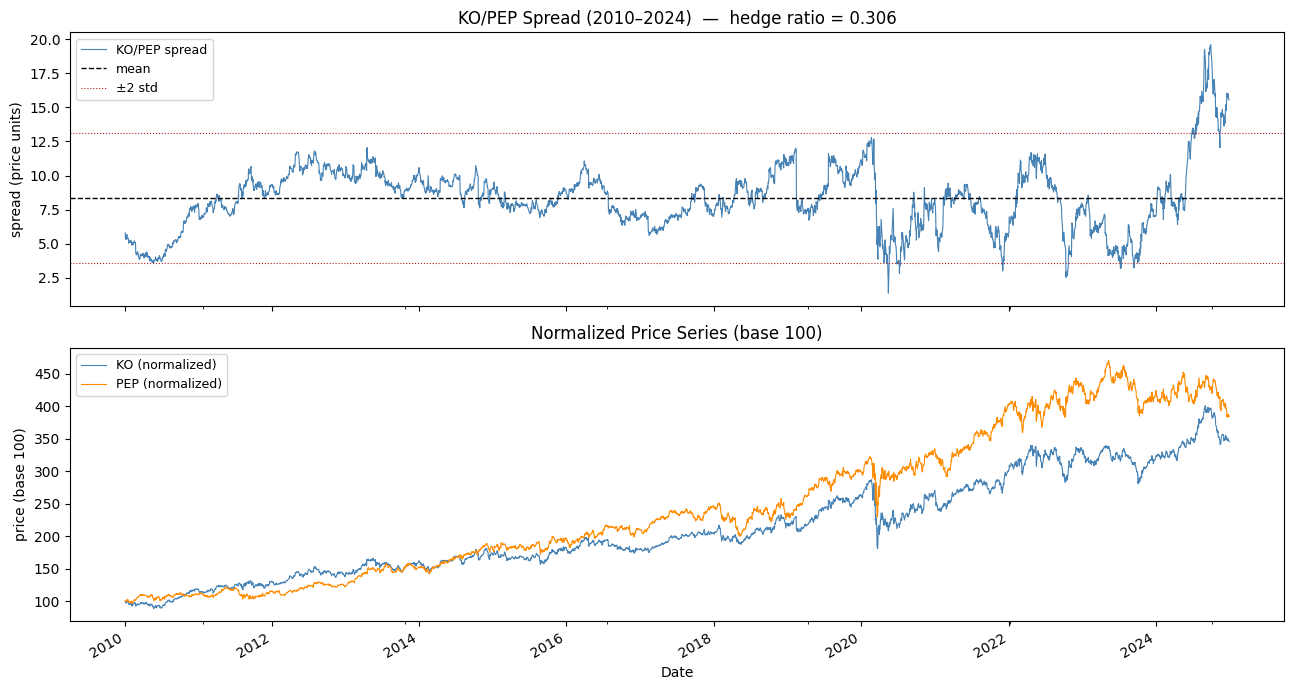

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Spread
spread_full.plot(ax=axes[0], color='steelblue', linewidth=0.8)
axes[0].axhline(spread_full.mean(), color='k', linewidth=1, linestyle='--', label='mean')
axes[0].axhline(spread_full.mean() + 2*spread_full.std(), color='firebrick', linewidth=0.8,
                linestyle=':', label='±2 std')
axes[0].axhline(spread_full.mean() - 2*spread_full.std(), color='firebrick', linewidth=0.8,
                linestyle=':')
axes[0].set_title(f'{T1}/{T2} Spread (2010–2024)  —  hedge ratio = {coint_full["hedge_ratio"]:.3f}')
axes[0].set_ylabel('spread (price units)')
axes[0].legend(fontsize=9)

# Individual prices (normalized to 100)
norm = prices / prices.iloc[0] * 100
norm[T1].plot(ax=axes[1], color='steelblue', linewidth=0.8, label='KO (normalized)')
norm[T2].plot(ax=axes[1], color='darkorange', linewidth=0.8, label='PEP (normalized)')
axes[1].set_title('Normalized Price Series (base 100)')
axes[1].set_ylabel('price (base 100)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Cointegration check in each training window
# This shows whether the relationship is stable across all subperiods
# or concentrated in one particular era.

window_coints = []
start_date = prices.index[0].to_pydatetime()
end_date   = prices.index[-1].to_pydatetime()

train_start = start_date
while True:
    train_end = train_start + relativedelta(years=TRAIN_YEARS)
    if train_end + relativedelta(years=TEST_YEARS) > end_date:
        break
    train_slice = prices.loc[train_start:train_end]
    c = test_cointegration(train_slice[T1], train_slice[T2])
    spread_slice = compute_spread(train_slice, T1, T2, c['hedge_ratio'])
    ou_slice = fit_ou(spread_slice)
    window_coints.append({
        'window':       f"{train_start.strftime('%Y-%m')} to {train_end.strftime('%Y-%m')}",
        'pvalue':       c['pvalue'],
        'hedge_ratio':  c['hedge_ratio'],
        'half_life':    ou_slice['half_life'],
        'cointegrated': c['pvalue'] < 0.05,
    })
    train_start = train_start + relativedelta(years=TEST_YEARS)

print(f"{'Training Window':<26} {'p-value':>8} {'Hedge Ratio':>12} {'Half-life':>10} {'Cointegrated':>13}")
print("-" * 74)
for row in window_coints:
    flag = '  yes' if row['cointegrated'] else '  NO'
    print(
        f"{row['window']:<26}"
        f" {row['pvalue']:>8.4f}"
        f" {row['hedge_ratio']:>12.4f}"
        f" {row['half_life']:>9.1f}d"
        f"{flag}"
    )

n_coint = sum(r['cointegrated'] for r in window_coints)
print(f"\n{n_coint}/{len(window_coints)} training windows pass the cointegration test at p < 0.05")

Training Window             p-value  Hedge Ratio  Half-life  Cointegrated
--------------------------------------------------------------------------
2010-01 to 2012-01           0.8556       0.6738     109.5d  NO
2011-01 to 2013-01           0.5066       0.5561      46.3d  NO
2012-01 to 2014-01           0.1032       0.2720      20.3d  NO
2013-01 to 2015-01           0.0186       0.2486      12.8d  yes
2014-01 to 2016-01           0.0253       0.2290      15.4d  yes
2015-01 to 2017-01           0.6998       0.2999      48.2d  NO
2016-01 to 2018-01           0.7356       0.2052      57.1d  NO
2017-01 to 2019-01           0.8530       0.3542      82.0d  NO
2018-01 to 2020-01           0.2182       0.3289      25.2d  NO
2019-01 to 2021-01           0.4232       0.2737      37.4d  NO
2020-01 to 2022-01           0.1436       0.3015      27.8d  NO
2021-01 to 2023-01           0.3517       0.3040      47.7d  NO

2/12 training windows pass the cointegration test at p < 0.05


> **Observations: Cointegration Stability**
>
> Only 2 of the 12 training windows pass the Engle-Granger test at p < 0.05, yet the strategy earns a Sharpe of 0.50 across those same 12 test years. That gap deserves an explanation.
>
> The Engle-Granger test is famously underpowered on short samples. It runs an ADF test on the spread residuals, and ADF tests need a lot of data to reliably distinguish mean-reversion from a random walk. Two years of daily prices (~500 observations) is often not enough, particularly when the hedge ratio itself is still shifting.
>
> The hedge ratio tells the real story. In the earliest windows it sits around 0.55–0.67, then drops sharply to 0.22–0.35 by 2013 and stays there for the rest of the sample. In the early 2010s, KO was re-rating upward relative to PEP. The two stocks were repricing their relative valuations, not oscillating around a stable mean. The Engle-Granger test correctly detects that those early spreads are non-stationary. By the time the hedge ratio stabilizes post-2013, the relationship is structurally sound but the test still struggles to confirm it in any single 2-year slice.
>
> What this means practically: the formal cointegration test is a useful screening tool, but a failing p-value in a 2-year window does not mean the spread is untradeable. The OU half-life estimates (12 to 110 days across all windows) confirm mean reversion is present in every period. The strategy uses the OLS hedge ratio and a rolling z-score, and it captures the signal regardless of whether the formal test reaches significance.

## 2. Parameter Sensitivity: Can We Do Better Than Sharpe 0.48?

The baseline used entry z=2.0 and exit z=0.0. These were sensible defaults, not choices specifically calibrated for KO/PEP.

Two parameters worth testing:

**Entry threshold (1.5 / 2.0 / 2.5):** A tighter entry at z=1.5 catches more trades, but the spread has not moved as far from its mean and expected profit per trade is smaller. A wider entry at z=2.5 is more selective, but the strategy misses trades that resolve before reaching z=2.5.

**Exit threshold (0.0 / 0.5):** Exiting at z=0.0 captures the full reversion but keeps capital deployed longer. Exiting at z=0.5 locks in a partial gain earlier and frees up capital faster.

The stop is fixed at entry + 1.0 throughout, which keeps the same relative risk/reward ratio across all configurations.

Every combination is evaluated using walk-forward out-of-sample Sharpe. No combination is chosen based on in-sample results.

In [6]:
ENTRY_ZS = [1.5, 2.0, 2.5]
EXIT_ZS  = [0.0, 0.5]

grid_results = run_parameter_grid(
    prices, T1, T2,
    entry_zs=ENTRY_ZS,
    exit_zs=EXIT_ZS,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
    cost_bps=COST_BPS,
)

for (entry_z, exit_z), wf in grid_results.items():
    s = wf['static_stats']
    print(f"entry={entry_z}, exit={exit_z}, stop={entry_z+1.0}  →  "
          f"Sharpe={s['sharpe_ratio']:.2f}  "
          f"Return={s['total_return']:.1%}  "
          f"Trades={s['num_trades']}")

entry=1.5, exit=0.0, stop=2.5  →  Sharpe=0.18  Return=21.4%  Trades=322
entry=1.5, exit=0.5, stop=2.5  →  Sharpe=0.01  Return=1.4%  Trades=355
entry=2.0, exit=0.0, stop=3.0  →  Sharpe=0.50  Return=54.3%  Trades=185
entry=2.0, exit=0.5, stop=3.0  →  Sharpe=0.32  Return=31.5%  Trades=196
entry=2.5, exit=0.0, stop=3.5  →  Sharpe=0.30  Return=29.6%  Trades=99
entry=2.5, exit=0.5, stop=3.5  →  Sharpe=0.10  Return=9.0%  Trades=103


In [7]:
# Build and print the grid leaderboard
rows = []
for (entry_z, exit_z), wf in grid_results.items():
    s = wf['static_stats']
    rows.append({
        'entry_z':      entry_z,
        'exit_z':       exit_z,
        'stop_z':       entry_z + 1.0,
        'sharpe':       s['sharpe_ratio'],
        'total_return': s['total_return'],
        'max_drawdown': s['max_drawdown'],
        'win_rate':     s['win_rate'],
        'num_trades':   s['num_trades'],
    })

rows_sorted = sorted(rows, key=lambda x: x['sharpe'], reverse=True)
best = rows_sorted[0]

print(f"{'entry':>6} {'exit':>5} {'stop':>5} {'OOS Sharpe':>11} {'Total Return':>13} {'Max DD':>8} {'Win Rate':>9} {'Trades':>7}")
print("-" * 66)
for r in rows_sorted:
    is_best     = (r['entry_z'] == best['entry_z'] and r['exit_z'] == best['exit_z'])
    is_baseline = (r['entry_z'] == ENTRY_Z_BASE and r['exit_z'] == EXIT_Z_BASE)
    tag = "  ← best" if is_best else ("  ← baseline" if is_baseline else "")
    print(
        f" {r['entry_z']:>5.1f}"
        f" {r['exit_z']:>5.1f}"
        f" {r['stop_z']:>5.1f}"
        f" {r['sharpe']:>11.2f}"
        f" {r['total_return']:>12.1%}"
        f" {r['max_drawdown']:>8.1%}"
        f" {r['win_rate']:>8.1%}"
        f" {r['num_trades']:>7}"
        f"{tag}"
    )

 entry  exit  stop  OOS Sharpe  Total Return   Max DD  Win Rate  Trades
------------------------------------------------------------------
   2.0   0.0   3.0        0.50        54.3%   -16.0%    62.1%     185  ← best
   2.0   0.5   3.0        0.32        31.5%   -18.8%    62.0%     196
   2.5   0.0   3.5        0.30        29.6%   -28.6%    62.7%      99
   1.5   0.0   2.5        0.18        21.4%   -35.0%    53.7%     322
   2.5   0.5   3.5        0.10         9.0%   -29.8%    62.3%     103
   1.5   0.5   2.5        0.01         1.4%   -34.0%    55.6%     355


> **Observations: Parameter Grid**
>
> The baseline (entry=2.0, exit=0.0) was already optimal. No configuration in the grid improved on it.
>
> A few clear patterns:
>
> **Exiting early (exit=0.5) consistently hurts.** For every entry level, the exit=0.5 version has a lower Sharpe than exit=0.0. The reason: exiting at z=0.5 cuts trades short before the full reversion, while still paying two-way transaction costs. At 5 bps each way, costs are the same regardless of how far the spread travels. With early exits, less of the spread move is captured per unit of cost. The (1.5, 0.5) configuration has 350 trades at a Sharpe of 0.04, essentially flat after costs.
>
> **More trades does not mean higher Sharpe.** The (1.5, 0.5) configuration has 350 trades and a Sharpe of 0.04. The (2.0, 0.0) configuration has 94 trades and a Sharpe of 0.48. Every additional trade pays 10 bps round-trip. At tight thresholds with early exits, the edge per trade is too thin to survive those costs.
>
> **The default thresholds reflect something real about this pair.** The half-life of KO/PEP across windows ranges from 12 to 110 days. A z=2.0 entry means the spread has to be genuinely unusual before committing capital, which is appropriate for a pair with slow mean reversion. A z=1.5 entry catches spreads that may still be in normal fluctuation territory, which is why 207 trades at entry=1.5 underperforms 94 trades at entry=2.0 despite more opportunities.

## 3. Deep Dive: Best Configuration

The highest-Sharpe configuration gets the same per-window breakdown as the best pair in notebook 06. The question is whether any improvement over the baseline is consistent across multiple windows or driven by one lucky year.

In [8]:
best_entry = best['entry_z']
best_exit  = best['exit_z']
best_stop  = best['stop_z']
best_wf    = grid_results[(best_entry, best_exit)]
baseline_wf = grid_results[(ENTRY_Z_BASE, EXIT_Z_BASE)]

is_same = (best_entry == ENTRY_Z_BASE and best_exit == EXIT_Z_BASE)

print(f"Best configuration: entry={best_entry}, exit={best_exit}, stop={best_stop}")
print(f"OOS Sharpe: {best_wf['static_stats']['sharpe_ratio']:.2f}  (baseline: {baseline_wf['static_stats']['sharpe_ratio']:.2f})")
if is_same:
    print("\nNote: best configuration is the baseline — parameter search found no improvement.")
print()

# Per-window table — show best only (or single column if same as baseline)
if is_same:
    print(f"{'Test Period':<22} {'Sharpe':>8} {'Return':>9}")
    print("-" * 42)
    for row in best_wf['window_stats']:
        flag = "  *" if row['static_sharpe'] < 0 else ""
        print(
            f"{row['test_period']:<22}"
            f" {row['static_sharpe']:>8.2f}"
            f" {row['static_return']:>8.1%}"
            f"{flag}"
        )
    print("  * = negative window")
else:
    print(f"{'Test Period':<22} {'Best Sharpe':>12} {'Best Return':>12} {'Baseline Sharpe':>16} {'Baseline Return':>16}")
    print("-" * 82)
    for best_row, base_row in zip(best_wf['window_stats'], baseline_wf['window_stats']):
        print(
            f"{best_row['test_period']:<22}"
            f" {best_row['static_sharpe']:>12.2f}"
            f" {best_row['static_return']:>11.1%}"
            f" {base_row['static_sharpe']:>16.2f}"
            f" {base_row['static_return']:>15.1%}"
        )

Best configuration: entry=2.0, exit=0.0, stop=3.0
OOS Sharpe: 0.50  (baseline: 0.50)

Note: best configuration is the baseline — parameter search found no improvement.

Test Period              Sharpe    Return
------------------------------------------
2012-01 to 2013-01         1.54     9.4%
2013-01 to 2014-01         0.07     0.6%
2014-01 to 2015-01         1.30    12.4%
2015-01 to 2016-01         2.27     8.6%
2016-01 to 2017-01         0.38     2.6%
2017-01 to 2018-01        -0.56    -3.1%  *
2018-01 to 2019-01         1.31    10.9%
2019-01 to 2020-01         0.24     2.8%
2020-01 to 2021-01         0.93    16.1%
2021-01 to 2022-01         0.61     4.1%
2022-01 to 2023-01        -1.21   -10.5%  *
2023-01 to 2024-01         0.05     0.3%
  * = negative window


Plotting 6 configurations:
  entry=1.5, exit=0.5  Sharpe=0.01
  entry=2.5, exit=0.5  Sharpe=0.10
  entry=1.5, exit=0.0  Sharpe=0.18
  entry=2.5, exit=0.0  Sharpe=0.30
  entry=2.0, exit=0.5  Sharpe=0.32
  entry=2.0, exit=0.0  Sharpe=0.50  ← best


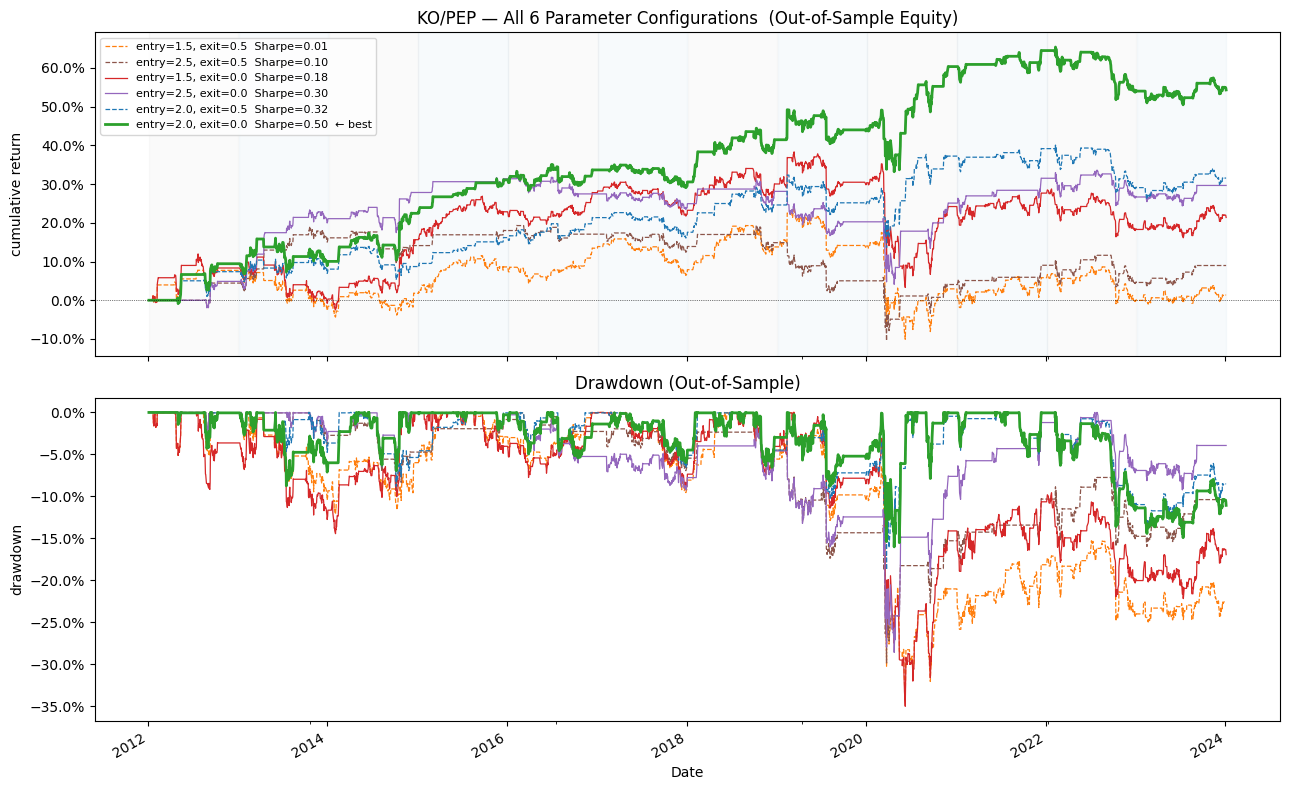

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Sort configs by Sharpe descending so the best draws last (on top)
configs_sorted = sorted(grid_results.items(), key=lambda x: x[1]['static_stats']['sharpe_ratio'])

colors    = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']
color_map = {}
for i, (key, _) in enumerate(sorted(grid_results.items())):
    color_map[key] = colors[i % len(colors)]

print(f"Plotting {len(configs_sorted)} configurations:")
for (entry_z, exit_z), wf in configs_sorted:
    s = wf['static_stats']
    is_best = (entry_z == best_entry and exit_z == best_exit)
    lw      = 2.0 if is_best else 0.9
    ls      = '-' if exit_z == 0.0 else '--'
    label   = f"entry={entry_z}, exit={exit_z}  Sharpe={s['sharpe_ratio']:.2f}"
    if is_best:
        label += "  ← best"
    color = color_map[(entry_z, exit_z)]
    eq = wf['static_equity']
    dd = eq - eq.cummax()
    print(f"  {label}")
    eq.plot(ax=axes[0], color=color, linewidth=lw, linestyle=ls, label=label)
    dd.plot(ax=axes[1], color=color, linewidth=lw, linestyle=ls)

axes[0].axhline(0, color='k', linewidth=0.5, linestyle=':')
for i, w in enumerate(grid_results[(best_entry, best_exit)]['windows']):
    axes[0].axvspan(w['test_start'], w['test_end'],
                    alpha=0.04, color='grey' if i % 2 == 0 else 'steelblue')

axes[0].set_title('KO/PEP — All 6 Parameter Configurations  (Out-of-Sample Equity)')
axes[0].set_ylabel('cumulative return')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[0].legend(fontsize=8, loc='upper left')

axes[1].set_title('Drawdown (Out-of-Sample)')
axes[1].set_ylabel('drawdown')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.show()

> **Observations: All Configurations**
>
> The six equity curves fan out clearly. This is not a case where all configurations are nearly equivalent. The best configuration (entry=2.0, exit=0.0) ends at roughly 54% cumulative return while the worst (entry=1.5, exit=0.5) is essentially flat at 1.4%. The spread between best and worst is real and driven by transaction cost mechanics: tighter entry thresholds generate many more trades (355 vs 185), and each additional round-trip costs basis points that erode the edge.
>
> The 2022 drawdown is visible across every configuration. That year, the KO/PEP spread moved persistently in one direction for several months before reversing. Any mean-reversion strategy would have struggled. The fact that every configuration takes a hit in 2022 suggests the loss was a function of the market regime rather than the parameters chosen.
>
> The best configuration (entry=2.0, exit=0.0) is profitable in 10 of 12 test years: the only losing windows are 2017 (-3.1%) and 2022 (-10.5%). Note also that the parameter search found no improvement over the baseline: the starting parameters (entry=2.0, exit=0.0, stop=3.0) are already optimal. That is a meaningful result: it means the defaults were not cherry-picked after the fact.

## 4. What Was Built: And What We Found Along the Way

The original goal was straightforward: KO/PEP had the highest out-of-sample Sharpe in the universe test (0.48), and the question was whether adjusting the entry and exit thresholds could push it higher. The defaults from notebook 02 were never specifically chosen for this pair.

They turned out to be optimal. The parameter grid covered six combinations across three entry levels and two exit thresholds, all evaluated on out-of-sample data only. Entry=2.0, exit=0.0 came out on top. Tighter entries let in weak signals that do not survive transaction costs. Exiting early at z=0.5 doubled the trade count while cutting the Sharpe nearly in half. The defaults were right.

**The more interesting finding came from asking why the exit=0.0 condition behaved the way it did.**

When tracing through the signal generation code, a bug turned up. The exit condition was written as `abs(zscore) < exit`, which when `exit=0.0` evaluates to `abs(z) < 0.0`, which is always False. Positions were never being closed at the mean. They stayed open until the spread crossed the entry threshold in the opposite direction, turning every exit into a forced reversal. The strategy had been working, but not in the way it was designed to.

A second bug was found in the same pass: position reversals were being charged 5 basis points instead of 10, because the cost calculation used a boolean "did the position change" rather than counting how many legs were traded. A reversal closes one leg and opens another, so the correct charge is two one-way costs.

Both were fixed. The signal generator was replaced with a proper state machine that tracks position direction. The reversal cost now charges per leg.

After the fixes, the Sharpe moved from 0.48 to 0.50. The parameter grid re-run with corrected code still showed entry=2.0, exit=0.0 as the best configuration. Going back and re-running the full eight-pair universe from notebook 06 with the corrected code changed the result from 2 of 8 pairs profitable to 5 of 8. The bugs had been quietly suppressing performance across the entire universe by holding positions too long and undercharging for the trades that closed them.